In [1]:
import numpy as np
from sympy import sin, cos 
import sympy as sp
import scipy as scp
import pandas as pd
from cmath import *
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import scienceplots
plt.style.context(['science'])
plt.rcParams['text.usetex'] = True
plt.rcParams["font.family"] = "Times New Roman"
import pickle
import timeit
import glob # need to merge arrays
import os # need to make directory
from scipy.interpolate import interp1d
from scipy.integrate import quad

import ternary

print("Version", ternary.__version__)

t0 = timeit.default_timer()

Version 1.0.8


In [640]:
def ini_composition_norm(x):
    arr = np.asarray(x, dtype=float)
    s = arr.sum()
    if s == 0:
        raise ValueError("Cannot normalize: sum of elements is zero.")
    return arr / s

In [642]:
ini_composition_norm([1,2,0]), ini_composition_norm([1,1,0])

(array([0.33333333, 0.66666667, 0.        ]), array([0.5, 0.5, 0. ]))

## prebuilt `NeutrinoHamiltonian` class

In [16]:
from scipy.linalg import expm

class NeutrinoHamiltonian:
    """
    Neutrino Hamiltonian with optional new-physics operators.

    Parameters
    ----------
    theta12, theta13, theta23 : float
        PMNS mixing angles in radians.
    delta_cp : float
        CP-violating phase in radians.
    dm21, dm31 : float
        Mass-squared differences (eV^2).
    E : float
        Neutrino energy (eV).
    n_terms : int
        Number of new-physics operators (default 2).
    seed : int, optional
        Random seed for reproducibility.
    O_n_list : list of 3x3 numpy arrays, optional
        List of diagonal operator matrices. Length must equal n_terms if given.
    Lambda_n_list : list of floats, optional
        List of new-physics energy scales (same length as n_terms if given).
    U_n_list : list of 3x3 unitary matrices, optional
        If not provided, random unitaries will be generated.
    """
    def __init__(self, theta12, theta13, theta23, delta_cp,
                 dm21, dm31, E,
                 n_terms=2,
                 seed=None,
                 O_n_list=None,
                 Lambda_n_list=None,
                 U_n_list=None):
        
        if seed is not None:
            np.random.seed(seed)

        # store parameters
        self.theta12 = theta12
        self.theta13 = theta13
        self.theta23 = theta23
        self.delta_cp = delta_cp
        self.dm21 = dm21
        self.dm31 = dm31
#         self.E = E
        self.n_terms = n_terms

        # PMNS mixing matrix
        self.U_pmns = self._pmns_matrix()

        # ---- handle optional new-physics inputs ----
        # O_n_list: diagonal 3x3 matrices
        if O_n_list is None:
            self.O_n_list = [self._random_diag() for _ in range(n_terms)]
        else:
            if len(O_n_list) != n_terms:
                raise ValueError("O_n_list length must match n_terms")
            self.O_n_list = O_n_list

        # U_n_list: unitary matrices
        if U_n_list is None:
            self.U_n_list = [self._random_unitary() for _ in range(n_terms)]
        else:
            if len(U_n_list) != n_terms:
                raise ValueError("U_n_list length must match n_terms")
            self.U_n_list = U_n_list

        # Lambda_n_list: energy scales
        if Lambda_n_list is None:
            self.Lambda_n_list = [1e-2 * (i + 1) for i in range(n_terms)]
        else:
            if len(Lambda_n_list) != n_terms:
                raise ValueError("Lambda_n_list length must match n_terms")
            self.Lambda_n_list = Lambda_n_list

        # precompute Hamiltonian and effective mixing
        self.H = self._total_hamiltonian(E)
        self.V_eff = self._effective_mixing_matrix()

    # ---------- helper methods ----------

    def _pmns_matrix(self):
        s12, s13, s23 = np.sin(self.theta12), np.sin(self.theta13), np.sin(self.theta23)
        c12, c13, c23 = np.cos(self.theta12), np.cos(self.theta13), np.cos(self.theta23)
        δ = self.delta_cp
        return np.array([
            [c12*c13, s12*c13, s13*np.exp(-1j*δ)],
            [-s12*c23 - c12*s23*s13*np.exp(1j*δ),
             c12*c23 - s12*s23*s13*np.exp(1j*δ),
             s23*c13],
            [s12*s23 - c12*c23*s13*np.exp(1j*δ),
             -c12*s23 - s12*c23*s13*np.exp(1j*δ),
             c23*c13]
        ], dtype=complex)

    def _random_diag(self):
        """Random diagonal 3×3 matrix with entries in [-1,1]."""
        return np.diag(np.random.uniform(-1, 1, 3))

    def _random_unitary(self):
        """Generate a random 3×3 unitary matrix using QR decomposition + phase fix."""
        Z = np.random.randn(3,3) + 1j*np.random.randn(3,3)
        Q, R = np.linalg.qr(Z)
        D = np.diag(np.exp(1j*np.angle(np.diag(R))))
        return Q @ D
    
#    ### wanted to exactly reproduce fig 8 from Mauricio 2503.15468 
#     def _dcn_LIV_hamiltonian(self, E):
#         H_dcn_LIV = np.zeros((3,3), dtype=complex)
        

    def _total_hamiltonian(self, E):
        """Vacuum + new-physics Hamiltonian in flavor basis."""
        H0 = self.U_pmns @ np.diag([0, self.dm21/(2*E), self.dm31/(2*E)]) @ self.U_pmns.conj().T
        H_new = np.zeros((3,3), dtype=complex)
        for n in range(self.n_terms):
            H_new += (E / self.Lambda_n_list[n])**n * self.O_n_list[n] * (
                self.U_n_list[n] @ np.diag(np.random.rand(3)) @ self.U_n_list[n].conj().T
            )
        return H0 + H_new

    def _show_distinct_hamiltonian(self, E):
        """Vacuum + new-physics Hamiltonian in flavor basis."""
        H0 = self.U_pmns @ np.diag([0, self.dm21/(2*E), self.dm31/(2*E)]) @ self.U_pmns.conj().T
        H_new = np.zeros((3,3), dtype=complex)
        for n in range(self.n_terms):
            H_new += (E / self.Lambda_n_list[n])**n * self.O_n_list[n] * (
                self.U_n_list[n] @ np.diag(np.random.rand(3)) @ self.U_n_list[n].conj().T
            )
            
        return H0, H_new
    
    def print_distinct_hamiltonian(self, E):
        H0, H_new = self._show_distinct_hamiltonian(E)
        print("H0=\n",H0)
        print("H_new=\n",H_new)
        return None
    
    def _effective_mixing_matrix(self):
        """Diagonalize total Hamiltonian to get effective mixing matrix."""
        _, evecs = np.linalg.eigh(self.H)
        return evecs

    def show_effective_mixing_matrix(self):
        """Diagonalize total Hamiltonian to get effective mixing matrix."""
        H0, H_new = self._show_distinct_hamiltonian(E)

        _, evecs_0 = np.linalg.eigh(self.H0)
        print("PMNS with LIV=0:\n",evecs0)

        _, evecs_LIV = np.linalg.eigh(self.H_new)
        print("PMNS with LIV=0:\n",H_new)
        
        return None


    def flavor_ratio(self, phi0, Eany):
        """
        Averaged flavor ratio at a single energy E (defaults to self.E).
        phi0 : array-like
            Initial flavor flux [phi_e, phi_mu, phi_tau].
        E : float, optional
            Energy in eV.  Uses self.E if not supplied.
        """
        if Eany is None:
            Eany = self.E
        Htot = self._total_hamiltonian(Eany)
        _, evecs = np.linalg.eigh(Htot)
        V = evecs

        Pbar = np.zeros((3,3))
        for α in range(3):
            for β in range(3):
                Pbar[α, β] = np.sum(np.abs(V[α, :])**2 * np.abs(V[β, :])**2)
        return Pbar @ phi0
    
    def flavor_ratio_integrated(self, phi0, E_bins, weights=None):
        """
        Integrate the flavor ratio over an array of energies.

        Parameters
        ----------
        phi0 : array-like
            Initial flavor flux [phi_e, phi_mu, phi_tau].
        E_bins : array-like
            1-D array of energies (eV) to integrate over.
        weights : array-like, optional
            Weights for each energy (e.g. flux spectrum). 
            If None, uses equal weighting.

        Returns
        -------
        np.ndarray
            Integrated/weighted average flavor ratio [phi_e, phi_mu, phi_tau].
        """
        E_bins = np.asarray(E_bins)
        if weights is None:
            weights = np.ones_like(E_bins)
        weights = np.asarray(weights)

        ratios = np.array([self.flavor_ratio(phi0, E) for E in E_bins])
        # weighted average across energies
        return np.average(ratios, axis=0, weights=weights)

In [19]:
# Example usage
theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.307)), 
                              np.arcsin(np.sqrt(0.02195)), 
                              np.arcsin(np.sqrt(0.561))]

delta_cp = 0
dm21, dm31 = 7.49e-5, 2.534e-3
phi0 = np.array([1, 0, 0])  # initial flavor ratio

# Example user-supplied new physics:
O_custom = [np.diag([0., 0., 0.]), 3.6e-26 * 1e9 * np.diag([1, 1, 1])]
Lambda_custom = [35*1e12, 35*1e12]

nu = NeutrinoHamiltonian(theta12, theta13, theta23, delta_cp,
                         dm21, dm31, 1e15,
                         n_terms=len(O_custom),
                         O_n_list=[
                             1.e-30 * 1e9,
                                   1.e-35 * 1e9
                         ],
                         Lambda_n_list=Lambda_custom,
                         seed=102)

phi0 = np.array([1, 2, 0])
print("Flavor ratio:", nu.flavor_ratio(phi0, 10e16))
print("Flavor ratio:", nu.flavor_ratio(phi0, 10e17))
print("Flavor ratio:", nu.flavor_ratio(phi0, 10e18))
print("Flavor ratio:", nu.flavor_ratio(phi0, 10e19))
print("Flavor ratio:", nu.flavor_ratio(phi0, 10e20))
print("Flavor ratio:", nu.flavor_ratio(phi0, 10e21))

# phi0 = np.array([1.5, 1.5, 0])
E_bins = np.logspace(8, 10, 50)  # 50 energies from 1e8 to 1e10 eV

phi_beta_avg = nu.flavor_ratio_integrated(phi0, E_bins)
print("Integrated flavor ratio:", phi_beta_avg)

nu.print_distinct_hamiltonian(1e18)
# # Energy bins from 1e8 to 1e15 eV (log-spaced)
# E_bins = np.logspace(8, 15, 20)
# phi_beta_avg = nu.flavor_ratio_integrated(phi0, E_bins)
# print("Averaged flavor ratio over energy bins:", phi_beta_avg)

Flavor ratio: [1.02113106 1.02498623 0.95388271]
Flavor ratio: [0.94709746 1.08801729 0.96488525]
Flavor ratio: [1.4017454  1.39523453 0.20302007]
Flavor ratio: [1.41725397 1.41614757 0.16659845]
Flavor ratio: [1.41358776 1.40500273 0.18140951]
Flavor ratio: [1.41463071 1.40829035 0.17707894]
Integrated flavor ratio: [1.0045644  1.033905   0.96153059]
H0=
 [[3.90554376e-23+0.j 1.49102209e-22+0.j 1.09089022e-22+0.j]
 [1.49102209e-22+0.j 7.04180015e-22+0.j 6.02524334e-22+0.j]
 [1.09089022e-22+0.j 6.02524334e-22+0.j 5.61214548e-22+0.j]]
H_new=
 [[ 1.10539604e-21+2.63768785e-38j  1.21413655e-23+2.93524996e-23j
  -4.21096483e-23-1.35351351e-23j]
 [ 1.21413655e-23-2.93524996e-23j  9.30731509e-22-5.58984365e-38j
   1.93659074e-23+7.08346283e-23j]
 [-4.21096483e-23+1.35351351e-23j  1.93659074e-23-7.08346283e-23j
   9.65781732e-22-1.46221875e-38j]]
Averaged flavor ratio over energy bins: [1.0045644  1.033905   0.96153059]


Flavor ratio: [1.41770454 1.41370642 0.16858904]


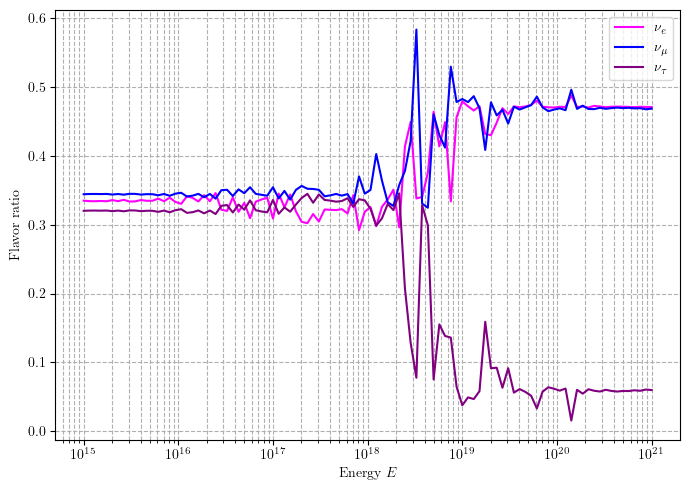

In [21]:
# Example usage
theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.307)), 
                              np.arcsin(np.sqrt(0.02195)), 
                              np.arcsin(np.sqrt(0.561))]

delta_cp = 0
dm21, dm31 = 7.49e-5, 2.534e-3
phi0 = np.array([1, 0, 0])  # initial flavor ratio

# Example user-supplied new physics:
O_custom = [np.diag([0., 0., 0.]), 3.6e-26 * 1e9 * np.diag([1, 1, 1])]
Lambda_custom = [35*1e12, 35*1e12]

nu = NeutrinoHamiltonian(theta12, theta13, theta23, delta_cp,
                         dm21, dm31, 1e10,
                         n_terms=len(O_custom),
                         O_n_list=[
                             1.e-30 * 1e9,
                             2.e-35 * 1e9
                         ],
                         Lambda_n_list=Lambda_custom,
                         seed=102
                        )

phi0 = np.array([1, 2, 0])
print("Flavor ratio:", nu.flavor_ratio(phi0, 10e19))

# Energy range
enrange = np.logspace(15, 21, 100)
# enrange = [10**x for x in np.linspace(18, 19, 10)]
# enrange = np.logspace(18, 19, 100)

# Evaluate flavor ratios
fractions = np.array([nu.flavor_ratio(phi0, e)/np.sum(phi0) for e in enrange])
frace   = fractions[:, 0]
fracmu  = fractions[:, 1]
fractau = fractions[:, 2]

# Plot
plt.figure(figsize=(7,5))
plt.plot(enrange, frace,   label=r'$\nu_e$', color='magenta')
plt.plot(enrange, fracmu,  label=r'$\nu_\mu$', color='blue')
plt.plot(enrange, fractau, label=r'$\nu_\tau$', color='purple')

plt.xscale('log')
plt.xlabel(r'Energy $E$')
plt.ylabel('Flavor ratio')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

## reproduce Mauricio plot 

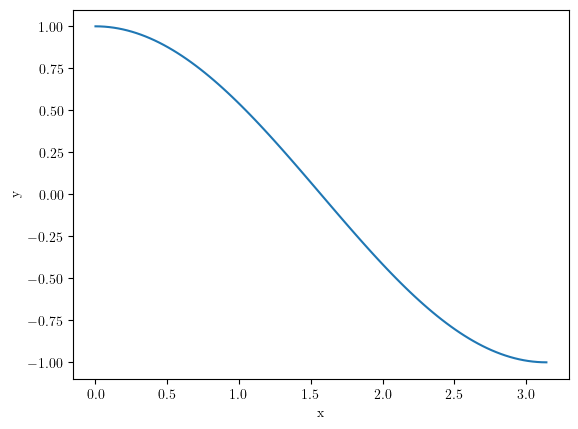

In [22]:
# for phi in np.linspace(0,2*pi,10):
#     print(phi, scp.special.sph_harm(0,1,phi,np.pi/4))
#     sph_harm(m, l, phi, theta)
check_ylm = []
for th in np.linspace(0,pi,100):
    check_ylm.append([th, np.real(np.sqrt(4*pi/3)* scp.special.sph_harm(0,1,0,th))])
    
np.shape(check_ylm)

check_ylm = np.array(check_ylm)
plt.figure()
plt.plot(check_ylm[:, 0], check_ylm[:, 1])#, marker='.')
plt.xlabel("x")
plt.ylabel("y")
plt.show()


Ylm works, I trust. 

In [621]:
from scipy.special import sph_harm

### eq 6, 2503.15468
def H_LIV_paper(E,theta,phi,d,a_eff=None,c_eff=None):
    """
    Compute H_LIV_paper^(d) in flavor space.

    Parameters
    ----------
    E : float
        Neutrino energy
    theta, phi : float
        Direction of momentum (polar, azimuth)
    d : int
        Operator dimension
    a_eff, c_eff : dict
        LIV coefficients indexed as:
        coeff[(l, m)] -> 3x3 complex matrix in flavor space

    Returns
    -------
    H : (3,3) complex ndarray
        LIV Hamiltonian in flavor space
    """
    d = int(d)
    H = np.zeros((3, 3), dtype=complex)

    prefactor = E**(d - 3)

    for l in range(d):
        for m in range(-l, l + 1):

            Ylm = sph_harm(m, l, phi, theta)

            if d % 2 == 1:  # CPT-odd
                if a_eff is None or (l, m) not in a_eff:
#                     print(f'a nai...(l,m)={(l,m)}')
                    continue
#                 print(f'a ache {prefactor} * {a_eff[(l, m)]}')
                H += prefactor * Ylm * a_eff[(l, m)]

            else:  # CPT-even
                if c_eff is None or (l, m) not in c_eff:
                    continue
                H -= prefactor * Ylm * c_eff[(l, m)]

    return H + H.conj().T


In [574]:
c_eff

{(2,
  2): array([[0.e+00+0.j, 0.e+00+0.j, 0.e+00+0.j],
        [0.e+00+0.j, 0.e+00+0.j, 0.e+00+0.j],
        [0.e+00+0.j, 0.e+00+0.j, 1.e-32+0.j]])}

In [661]:
d = 4  # CPT-even
c_eff = {}
# initialize (l=2, m=2) coefficient matrix
c_22 = np.zeros((3, 3), dtype=complex)
# flavor indices: e=0, mu=1, tau=2
c_22[2, 2] = 1e-34  # GeV^{-2}
c_22[2, 2] = 1e-32  # GeV^{-2}


# store in coefficient dictionary
c_eff[(2, 2)] = c_22


# --------------------------------------------------
# Evaluate H_LIV
# --------------------------------------------------

E = 1e6            # GeV
theta = np.pi / 3 # polar angle
phi = np.pi / 4   # azimuthal angle

np.abs(H_LIV_paper(E, theta, phi, d, c_eff=c_eff)[2,2]) , dm31/E

(3.5478709882567283e-43, 2.534e-27)

In [660]:
H_LIV_paper(E, theta, phi, d, c_eff=c_eff)

array([[ 0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  0.00000000e+00+0.j, -3.54787099e-43+0.j]])

In [622]:
H_LIV_paper(E, theta, phi, 3, a_eff={(2, 2):c_22})

array([[0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j],
       [0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j],
       [0.00000000e+00+0.j, 0.00000000e+00+0.j, 3.54787099e-53+0.j]])

In [126]:
d = 4  # CPT-even
c_eff = {}
# initialize (l=2, m=2) coefficient matrix
c_22 = np.zeros((3, 3), dtype=complex)
# flavor indices: e=0, mu=1, tau=2
c_22[2, 2] = 1e-34  # GeV^{-2}

# store in coefficient dictionary
c_eff[(2, 2)] = c_22
theta = np.pi / 3 # polar angle
phi = np.pi / 4   # azimuthal angle
E=1e6
# print(E, theta, phi, d, c_eff)
print(H_LIV_paper(E, theta, phi, d, c_eff=c_eff))

[[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  -1.77393549e-45-2.89705652e-29j]]


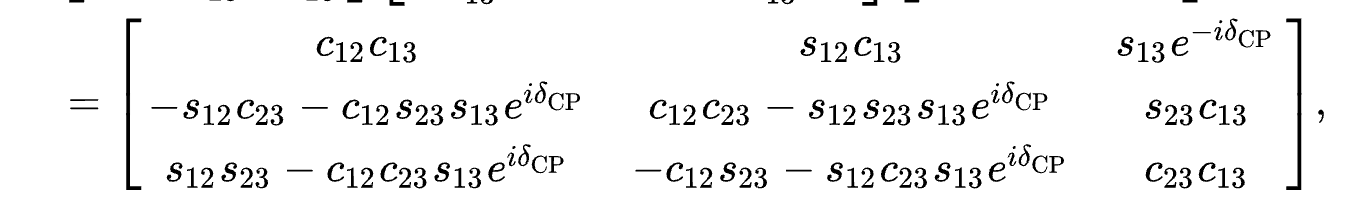

In [605]:
def pmns_matrix(theta12, theta23, theta13, delta):

    s12, s13, s23 = np.sin(theta12), np.sin(theta13), np.sin(theta23)
    c12, c13, c23 = np.cos(theta12), np.cos(theta13), np.cos(theta23)

    return np.array([
        [c12*c13, s12*c13, s13*np.exp(-1j*delta)],
        [-s12*c23 - c12*s23*s13*np.exp(1j*delta),
         c12*c23 - s12*s23*s13*np.exp(1j*delta),
         s23*c13],
        [s12*s23 - c12*c23*s13*np.exp(1j*delta),
         -c12*s23 - s12*c23*s13*np.exp(1j*delta),
         c23*c13]
    ], dtype=complex)

def H0_flavor(E, dm21, dm31, theta12, theta23, theta13, delta):
    """Vacuum Hamiltonian in flavor basis."""
    U_pmns = pmns_matrix(theta12, theta23, theta13, delta)
    H0 = U_pmns @ np.diag([0, dm21/(2*E), dm31/(2*E)]) @ U_pmns.conj().T
    return H0 

def prob_avg(E, dm21, dm31, theta12, theta23, theta13, delta,
            theta, phi, d, a_eff=None, c_eff=None):

    H0 = H0_flavor(E, dm21, dm31, theta12, theta23, theta13, delta)
    HLIV = H_LIV_paper(E, theta, phi, d, a_eff=a_eff, c_eff=c_eff)
    Htot = H0 + HLIV
    _, evecs = np.linalg.eigh(Htot)
    V = evecs

    avgP = np.zeros((3,3))
    for alpha in range(3):
        for beta in range(3):
            avgP[alpha, beta] = np.sum(np.abs(V[alpha, :])**2 * np.abs(V[beta, :])**2)

    return avgP 

In [298]:
theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.303)), 
                              np.arcsin(np.sqrt(0.02225)), 
                              np.arcsin(np.sqrt(0.572))]

delta = 197*np.pi/180

print(np.array([theta12, theta13, theta23])*180/np.pi)
dm21, dm31 = np.array([7.49e-5, 2.534e-3])*1e-18

np.abs(pmns_matrix(theta12, theta23, theta13, delta))

[33.3981894   8.57850189 49.13968785]


array([[0.82552514, 0.54429611, 0.14916434],
       [0.27144791, 0.60584076, 0.74784557],
       [0.49479721, 0.58025746, 0.64689798]])

In [628]:
c_eff = {}
# initialize (l=2, m=2) coefficient matrix
c_22 = np.zeros((3, 3), dtype=complex)
# flavor indices: e=0, mu=1, tau=2
#         c_22[2, 2] = 1e-36  # GeV^{-2}
c_22[alpha, beta] = cxfactor*1e-36  # GeV^{-2}
# store in coefficient dictionary
c_eff[(2, 0)] = c_22
a_eff = c_eff# np.copy(c_eff)

for d in range(3,8):
    prob_avg_matrix = prob_avg(Emax, dm21, dm31, 
            theta12, theta23, theta13, delta,
            theta, phi, d, a_eff, c_eff)

    print(prob_avg_matrix@[1,0,0]/1)

# prob_avg_matrix = prob_avg(Emax, dm21, dm31, 
#         theta12, theta23, theta13, delta,
#         theta, phi, 4, a_eff, c_eff)

# print(prob_avg_matrix)

# prob_avg_matrix = prob_avg(Emax, dm21, dm31, 
#         theta12, theta23, theta13, delta,
#         theta, phi, 5, a_eff, c_eff)

# print(prob_avg_matrix)

# prob_avg_matrix = prob_avg(Emax, dm21, dm31, 
#         theta12, theta23, theta13, delta,
#         theta, phi, 6, a_eff, c_eff)

# print(prob_avg_matrix)


# prob_avg_matrix = prob_avg(Emax, dm21, dm31, 
#         theta12, theta23, theta13, delta,
#         theta, phi, 7, a_eff, c_eff)

# print(prob_avg_matrix)

[0.55269493 0.17139841 0.27590665]
[0.94434727 0.04778994 0.00786279]
[9.37179081e-01 6.28209189e-02 1.23182250e-18]
[5.11251017e-01 4.88748983e-01 1.31344177e-32]
[1.00000000e+00 2.92018755e-19 2.06723010e-50]


In [510]:
print(H0_flavor(E, dm21, dm31, theta12, theta23, theta13, delta))

d = 4  # CPT-even
c_eff = {}
# initialize (l=2, m=2) coefficient matrix
c_22 = np.zeros((3, 3), dtype=complex)
# flavor indices: e=0, mu=1, tau=2
c_22[2, 2] = 1e-34  # GeV^{-2}

# store in coefficient dictionary
c_eff[(2, 2)] = c_22

print("H_LIV_paper\n",H_LIV_paper(E, theta, phi, d, c_eff=c_eff))
# --------------------------------------------------
# Evaluate H_LIV
# --------------------------------------------------

E = 1e5            # GeV
theta = np.pi / 30 # polar angle
phi = np.pi / 4   # azimuthal angle

prob_avg(E, dm21, dm31, theta12, theta23, theta13, delta,
            theta, phi, d, c_eff=c_eff)

[[ 3.92856215e-28-4.89961168e-45j -1.22816679e-27+4.09526295e-28j
  -1.28739513e-27+3.54246577e-28j]
 [-1.22816679e-27-4.09526295e-28j  7.22344653e-27-1.57672534e-46j
   5.99805101e-27-7.50567703e-30j]
 [-1.28739513e-27-3.54246577e-28j  5.99805101e-27+7.50567703e-30j
   5.42819726e-27+6.58871158e-48j]]
H_LIV_paper
 [[ 0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  0.00000000e+00+0.j -5.16863289e-48+0.j]]


array([[0.55269502, 0.17139837, 0.27590661],
       [0.17139837, 0.4529362 , 0.37566543],
       [0.27590661, 0.37566543, 0.34842796]])

In [366]:
theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.303)), 
                              np.arcsin(np.sqrt(0.02225)), 
                              np.arcsin(np.sqrt(0.572))]

delta = 197*np.pi/180
E=1e3
fracvalue = prob_avg(E, dm21, dm31, theta12, theta23, theta13, delta,
            theta, phi, d, c_eff={(2,2):0}) @ [1,2,0]
fracvalue/sum(fracvalue)

array([0.29849725, 0.35909026, 0.34241249])

In [367]:
prob_avg(E, dm21, dm31, 
            theta12, theta23, theta13, delta,
            theta, phi, d, c_eff)@[1,2,0]/3

array([0.29849725, 0.35909026, 0.34241249])

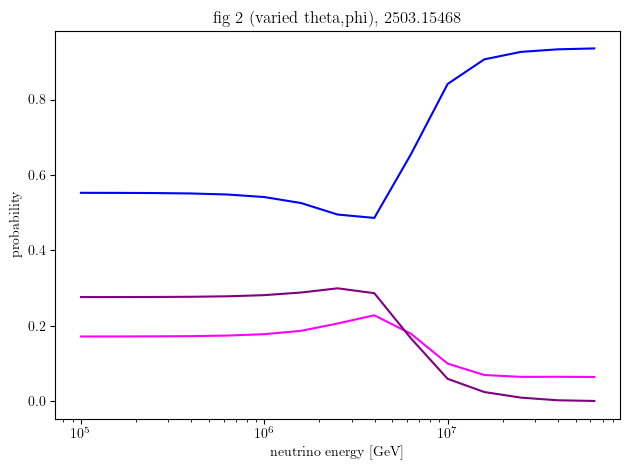

In [289]:
energylist = []
eelist = []
emulist = []
etaulist = []

for epx in np.arange(1,4,0.2):
#     del E
    E = float(10**(4+epx))
    energylist.append(E)
    theta = np.pi / 13 # polar angle
    phi = np.pi / 40   # azimuthal angle

    prob_avg_matrix = prob_avg(E, dm21, dm31, 
                theta12, theta23, theta13, delta,
                theta, phi, d, c_eff)
    
    eelist.append(prob_avg_matrix[0,0])
    emulist.append(prob_avg_matrix[0,1])
    etaulist.append(prob_avg_matrix[0,2])

plt.plot(energylist, eelist, color='blue')
plt.plot(energylist, emulist, color='magenta')
plt.plot(energylist, etaulist, color='purple')
plt.xscale('log')
plt.xlabel(r"neutrino energy [GeV]")
plt.ylabel(r"probability")
plt.title(r"fig 2 (varied theta,phi), 2503.15468")
plt.tight_layout()
plt.show()

In [26]:
# density rho_src
def rho_SFR(z):
    """
    Cosmic star formation rate density \dot{rho}_*(z)

    Units:
    rho_0 = Msun yr^{-1} Mpc^{-3}
    """

    # ----------------------------
    # Fixed parameters (eq 5 from 0804.4008)
    # ----------------------------
    rho0 = 1        # Msun yr^-1 Mpc^-3

    a = 3.4
    b = -0.3
    c = -3.5

    eta = -10.0

    # Break parameters
#     B = 5000
#     C = 9
    z1 = 1.0
    z2 = 4.0

    B = (1 + z1)**(1 - a / b)
    C = (1 + z1)**((b - a) / c) * (1 + z2)**(1 - b / c)

#     print(B,C)
    # ----------------------------
    # Star formation rate density
    # ----------------------------
    term1 = (1 + z)**(a * eta)
    term2 = ((1 + z) / B)**(b * eta)
    term3 = ((1 + z) / C)**(c * eta)

#     return rho0 * ( term1 +term2 + term3)
    return rho0 * (term1 + term2 + term3)**(1 / eta)


In [31]:
rho_SFR(1),rho_SFR(4)

(9.849155306759242, 7.481987582580969)

In [1229]:
del rho_SFR

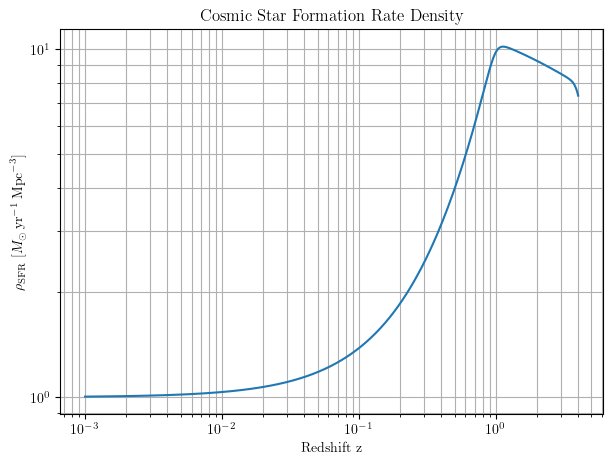

In [1207]:
z = np.logspace(-3, np.log10(4), 500)
rho = rho_SFR(z)

plt.figure(figsize=(7, 5))
plt.plot(z, rho)
plt.xlabel("Redshift z")
plt.ylabel(r"$\rho_{\rm SFR}\;[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{Mpc}^{-3}]$")
plt.xscale('log')
plt.yscale('log')
plt.title("Cosmic Star Formation Rate Density")
plt.grid(True, which="both")#, ls="--")
plt.show()


In [1255]:
# Constants
c = 3.0e5  # speed of light in km/s
H0 = 70.0  # Hubble constant in km/s/Mpc
Omega_m = 0.3  # Matter density parameter
Omega_Lambda = 0.7  # Dark energy density parameter

# Function for Hubble parameter H(z)
def H(z):
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda)

# Comoving distance function D_c(z)
def D_c(z):
    integrand = lambda z_prime: c / (H0 * np.sqrt(Omega_m * (1 + z_prime)**3 + Omega_Lambda))
    result, _ = quad(integrand, 0, z)
    return result

# Volume element dV/dz
def dV_dz(z):
    return 4 * np.pi * D_c(z)**2 * c / H(z)

# Function to compute N(z_max)
def N(z_max):
    integrand = lambda z: (rho_SFR(z) * dV_dz(z)) / (1 + z)
    result, _ = quad(integrand, 1e-100, z_max)
    return result

# Example usage
z_max = 1.0  # You can change z_max to any value you're interested in
N_result = N(z_max)
print(f"The number of mergers up to z = {z_max} is: {N_result}")

z_max = 4.0  # You can change z_max to any value you're interested in
N_result = N(z_max)
print(f"The number of stars up to z = {z_max} is: {N_result}")

print(N(4)/N(1))

The number of mergers up to z = 1.0 is: 551084488177.7847
The number of mergers up to z = 4.0 is: 4392241344496.084
7.97017778348192


In [303]:
# ------------------------
# Cosmology
# ------------------------
H0 = 70.0  # km/s/Mpc
Omega_m = 0.3
Omega_L = 0.7

def h(z):
    """Dimensionless Hubble parameter H(z)/H0"""
    return np.sqrt(Omega_m * (1 + z)**3 + Omega_L)

# ------------------------
# Flavor transition probability
# Placeholder (standard oscillations or LIV-modified)
# ------------------------
def P_beta_to_alpha(beta, alpha, 
                    E, dm21, dm31, 
                    theta12, theta23, theta13, delta,
                    theta, phi, d, c_eff):
    """
    Neutrino flavor transition probability
    Replace with your own oscillation/LIV model
    """
    # Example: averaged oscillations
    flavor_dict = { 'e': 0, 'mu': 1, 'tau': 2 }
    idxbeta = flavor_dict[beta]
    idxalpha = flavor_dict[alpha]
    prob_avg_matrix = prob_avg(E, dm21, dm31, 
                theta12, theta23, theta13, delta,
                theta, phi, d, c_eff)
    return prob_avg_matrix[idxbeta, idxalpha]

for E in [10**x for x in range(3,18)]:
    print(np.log10(E), P_beta_to_alpha('mu', 'e', 
                        E, dm21, dm31, 
                        theta12, theta23, theta13, delta,
                        theta, phi, d, c_eff))

3.0 0.17139837336028832
4.0 0.17139898852588353
5.0 0.17146049810662162
6.0 0.17753369386025636
7.0 0.09954710526300511
8.0 0.06335241143804782
9.0 0.06282679311602568
10.0 0.06282097060043773
11.0 0.0628209133627835
12.0 0.06282095217640832
13.0 0.06282618102131646
14.0 0.06253878147896158
15.0 0.0978409278360651
16.0 3.711186239988889e-05
17.0 0.4887489827303033


In [382]:
# ------------------------
# Flux computation
# ------------------------
def Phi_alpha(
    E, alpha,
    dm21, dm31, 
    theta12, theta23, theta13, delta,
    theta, phi, d, c_eff,
    z_max=4.0,
    Phi0=1.0,
    gamma=2.7,
    f_beta_S_input={'e': 1, 'mu': 2, 'tau': 0},
):
    """
    Compute diffuse neutrino flux Phi_alpha(E)
    """

    total = sum(f_beta_S_input.values())
#     f_beta_S = {k: v / total for k, v in f_beta_S_input.items()}
    f_beta_S = [v / total for k, v in f_beta_S_input.items()]
    
    def integrand(z):
        Ez = E * (1 + z)

        flavor_sum = 0.0
        prob_avg_matrix = prob_avg(Ez, dm21, dm31, 
            theta12, theta23, theta13, delta,
            theta, phi, d, c_eff)
        flavor_sum = prob_avg_matrix @ f_beta_S
        
        """
        ### useless
        for beta in ['e', 'mu', 'tau']:
            P = P_beta_to_alpha(beta, alpha, 
                    E, dm21, dm31, 
                    theta12, theta23, theta13, delta,
                    theta, phi, d, c_eff)
            
            
            
            flavor_sum += P * f_beta_S[beta]
        """
        flavor_dict = { 'e': 0, 'mu': 1, 'tau': 2 }

        return (
            rho_SFR(z)
            / (h(z) * (1 + z)**2)
            * Ez**(2 - gamma)
            * flavor_sum[flavor_dict[alpha]]
            )
        
    
#     return integrand(1)
    integral, _ = quad(integrand, 0, z_max, epsabs=1e-8)
    return Phi0 * integral / E**2

# ------------------------
# Example usage
# ------------------------
# E = 1e9  # GeV
# phi_mu = Phi_alpha(E, alpha='mu', dm21=dm21, dm31=dm31, 
#     theta12=theta12, theta23=theta23, theta13=theta13, delta=delta,
#     theta=theta, phi=phi, d=d, c_eff=c_eff)

# print(f"Phi_mu(E={E:.1e} GeV) = {phi_mu:.3e}")
# Phi_alpha(E, alpha='e'),Phi_alpha(E, alpha='mu'),Phi_alpha(E, alpha='tau')

In [385]:
E = 1e8
theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.303)), 
                              np.arcsin(np.sqrt(0.02225)), 
                              np.arcsin(np.sqrt(0.572))]

delta = 197*np.pi/180

ratio_test = []
for flav in ['e','mu','tau']:
    ratio_test.append(Phi_alpha(E, flav, dm21, dm31, 
              theta12, theta23, theta13, delta,
              theta, phi, d, c_eff))

np.array(ratio_test)/sum(ratio_test)

array([3.54341189e-01, 6.45450890e-01, 2.07920571e-04])

#### no integration 

In [386]:
def print_ratio_nointgr(
    dm21, dm31,
    theta12, theta23, theta13, delta,
    d, c_eff,
    E, n_theta, n_phi,
    f_beta_S_input={'e': 1, 'mu': 2, 'tau': 0},
):
    flavors = ['e', 'mu', 'tau']
    phi_vals = {}

        # Compute integrated fluxes
    for flav in flavors:

        theta_grid = np.linspace(0.0, np.pi, n_theta)
        phi_grid   = np.linspace(0.0, 2*np.pi, n_phi)

        dtheta = theta_grid[1] - theta_grid[0]
        dphi   = phi_grid[1] - phi_grid[0]
        total = 0 
        for theta in theta_grid:
            sin_theta = np.sin(theta)
            for phi in phi_grid:
                total += (
                    Phi_alpha(
                        E, flav,
                        dm21, dm31,
                        theta12, theta23, theta13, delta,
                        theta, phi, d, c_eff,
                        f_beta_S_input=f_beta_S_input
                    )
                    * sin_theta
                )

            phi_vals[flav] = total * dtheta * dphi


    total_flux = sum(phi_vals.values())

    if total_flux == 0:
        raise ValueError("Total integrated flux is zero.")

    # Compute ratios
    ratio_dict = {flav: phi_vals[flav] / total_flux for flav in flavors}
    return ratio_dict

In [387]:
E=1e3
for flav in ['e','mu','tau']:
    print(Phi_alpha(E, flav,
            dm21, dm31,
            theta12, theta23, theta13, delta,
            theta, phi, d, c_eff,
            f_beta_S_input={'e': 1, 'mu': 2, 'tau': 0}))

3.6129850896615977e-09
4.346397634829116e-09
4.144531352150443e-09


In [388]:
print_ratio_nointgr(
                dm21, dm31,
                theta12, theta23, theta13, delta,
                d, c_eff,
                1e3, n_theta=4, n_phi=4,
                f_beta_S_input={'e': 1, 'mu': 2, 'tau': 0},
                )


{'e': 0.29849725428525586,
 'mu': 0.35909026096918883,
 'tau': 0.3424124847455554}

In [408]:
Emax_list = np.logspace(4, 8, 12)   # change number of points if needed
Emin = 1.0

# storage
eratio  = []
muratio = []
tauratio = []
delta=0
for im, Emax in enumerate(Emax_list):
    print(im)

    theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.303)), 
                                  np.arcsin(np.sqrt(0.02225)), 
                                  np.arcsin(np.sqrt(0.572))]

    delta = 197*np.pi/180

    ratio_dict = print_ratio_nointgr(
                dm21, dm31,
                theta12, theta23, theta13, delta,
                d, c_eff,
                Emax, n_theta=4, n_phi=4,
                f_beta_S_input={'e': 1, 'mu': 2, 'tau': 0},
                )

    # read dictionary
    eratio.append(ratio_dict['e'])
    muratio.append(ratio_dict['mu'])
    tauratio.append(ratio_dict['tau'])

0
1
2
3
4
5
6
7
8
9
10
11


In [409]:
theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.303)), 
                              np.arcsin(np.sqrt(0.02225)), 
                              np.arcsin(np.sqrt(0.572))]

delta = 197*np.pi/180

print_ratio_nointgr(
                dm21, dm31,
                theta12, theta23, theta13, delta,
                d, c_eff,
                1e3, n_theta=4, n_phi=4,
                f_beta_S_input={'e': 1, 'mu': 2, 'tau': 0},
                )

{'e': 0.29849725428525586,
 'mu': 0.35909026096918883,
 'tau': 0.3424124847455554}

In [410]:
eratio

[0.2984975876581002,
 0.2984990869307423,
 0.29850816188921026,
 0.29858727064199997,
 0.29976250715270747,
 0.31052579174070744,
 0.3333718261783228,
 0.3451406283357824,
 0.3520697244284053,
 0.35409737249056966,
 0.35425502007778237,
 0.3542706612581525]

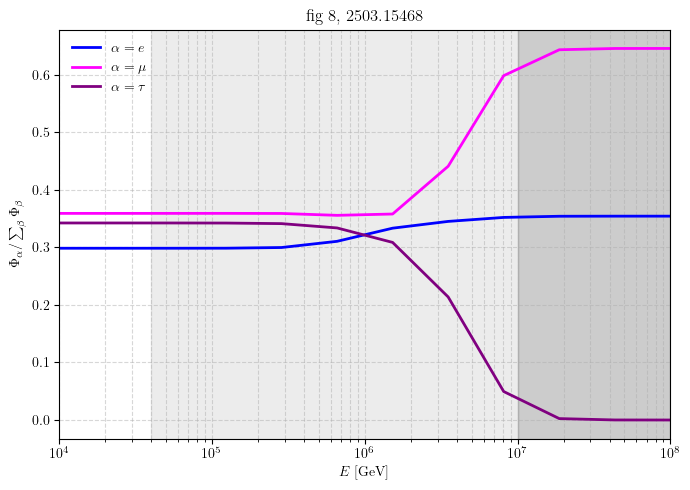

In [427]:
plt.figure(figsize=(7,5))

plt.plot(Emax_list, eratio,  color='blue',    lw=2, label=r'$\alpha=e$')
plt.plot(Emax_list, muratio, color='magenta', lw=2, label=r'$\alpha=\mu$')
plt.plot(Emax_list, tauratio, color='purple', lw=2, label=r'$\alpha=\tau$')

plt.xscale('log')
plt.xlabel(r'$E$ [GeV]')
plt.ylabel(r'$\Phi_\alpha/\sum_\beta \Phi_\beta $')
plt.xlim(1e4,1e8)

# shaded regions
plt.axvspan(4e4, 1e7, color='gray', alpha=0.15)   # first shade
plt.axvspan(1e7, 1e8, color='gray', alpha=0.4)  # second shade

plt.legend(frameon=False)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.title('fig 8, 2503.15468')
plt.tight_layout()
plt.show()

### scan i) move to right, ii) $f_\tau >1/3$

In [435]:
Emax_list = np.logspace(4, 8, 6)   # change number of points if needed
Emin = 1.0

# storage
eratio  = []
muratio = []
tauratio = []
delta=0
for im, Emax in enumerate(Emax_list):
    print(im)

    theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.303)), 
                                  np.arcsin(np.sqrt(0.02225)), 
                                  np.arcsin(np.sqrt(0.572))]

    delta = 197*np.pi/180

    c_eff = {}
    # initialize (l=2, m=2) coefficient matrix
    c_22 = np.zeros((3, 3), dtype=complex)
    # flavor indices: e=0, mu=1, tau=2
    c_22[2, 2] = 1e-36  # GeV^{-2}

    # store in coefficient dictionary
    c_eff[(2, 2)] = c_22

    ratio_dict = print_ratio_nointgr(
                dm21, dm31,
                theta12, theta23, theta13, delta,
                d, c_eff,
                Emax, n_theta=4, n_phi=4,
                f_beta_S_input={'e': 1, 'mu': 2, 'tau': 0},
                )

    # read dictionary
    eratio.append(ratio_dict['e'])
    muratio.append(ratio_dict['mu'])
    tauratio.append(ratio_dict['tau'])

0
1
2
3
4
5


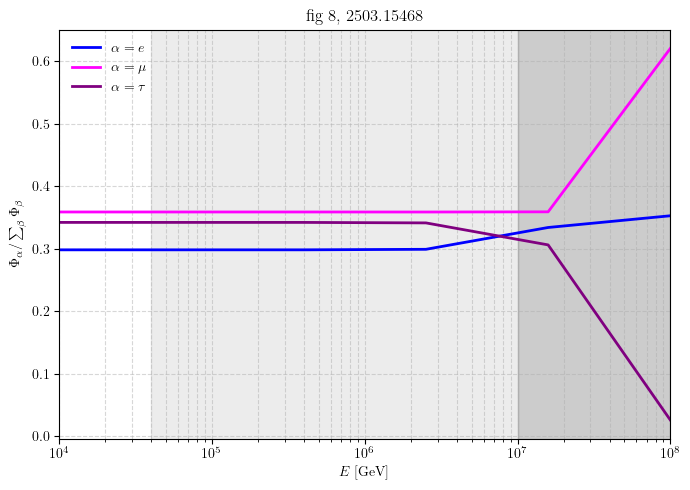

In [436]:
plt.figure(figsize=(7,5))

plt.plot(Emax_list, eratio,  color='blue',    lw=2, label=r'$\alpha=e$')
plt.plot(Emax_list, muratio, color='magenta', lw=2, label=r'$\alpha=\mu$')
plt.plot(Emax_list, tauratio, color='purple', lw=2, label=r'$\alpha=\tau$')

plt.xscale('log')
plt.xlabel(r'$E$ [GeV]')
plt.ylabel(r'$\Phi_\alpha/\sum_\beta \Phi_\beta $')
plt.xlim(1e4,1e8)

# shaded regions
plt.axvspan(4e4, 1e7, color='gray', alpha=0.15)   # first shade
plt.axvspan(1e7, 1e8, color='gray', alpha=0.4)  # second shade

plt.legend(frameon=False)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.title('fig 8, 2503.15468')
plt.tight_layout()
plt.show()

In [453]:
np.logspace(0, 3, 6)

array([   1.        ,    3.98107171,   15.84893192,   63.09573445,
        251.18864315, 1000.        ])

In [501]:
Emax_list = np.logspace(4, 8, 6)   # change number of points if needed
Emin = 1.0

# storage
eratio  = []
muratio = []
tauratio = []
delta=0
    
for alpha in range(3):
    for beta in range(3):
        theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.303)), 
                                      np.arcsin(np.sqrt(0.02225)), 
                                      np.arcsin(np.sqrt(0.572))]

        delta = 197*np.pi/180
        
        for cxfactor in np.logspace(-45, 45, 80):
            c_eff = {}
            # initialize (l=2, m=2) coefficient matrix
            c_22 = np.zeros((3, 3), dtype=complex)
            # flavor indices: e=0, mu=1, tau=2
    #         c_22[2, 2] = 1e-36  # GeV^{-2}
            c_22[alpha, beta] = cxfactor*1e-36  # GeV^{-2}
            # store in coefficient dictionary
            c_eff[(2, 0)] = c_22

#             ratio_dict = print_ratio_nointgr(
#                         dm21, dm31,
#                         theta12, theta23, theta13, delta,
#                         d, c_eff,
#                         Emax, n_theta=4, n_phi=4,
#                         f_beta_S_input={'e': 1, 'mu': 2, 'tau': 0},
#                         )
            prob_avg_matrix = prob_avg(Emax, dm21, dm31, 
                        theta12, theta23, theta13, delta,
                        theta, phi, d, c_eff)
            # read dictionary
        #     eratio.append(ratio_dict['e'])
        #     muratio.append(ratio_dict['mu'])

        #     tauratio.append(ratio_dict['tau'])
#             comp = (prob_avg_matrix @ [1/3,2/3,0])[2]
            comp = (prob_avg_matrix @ [1,0,0])[2]
            tauratio.append(taucomp)
            if comp>0.35:
                print("found one:")
                print(alpha, beta, cxfactor, comp)

found one:
0 2 3.7121050090663723 0.4736054491764222
found one:
0 2 51.15178099293187 0.4998648773035069
found one:
0 2 704.8574036452004 0.49999928791608816
found one:
0 2 9712.740198471207 0.4999999962496421
found one:
0 2 133838.875317377 0.4999999999802491
found one:
0 2 1844262.708585563 0.49999999999989564
found one:
0 2 25413430.367026497 0.4999999999999992
found one:
0 2 350190046.1431749 0.4999999999999996
found one:
0 2 4825522042.741358 0.4999999999999997
found one:
0 2 66494359966.65086 0.5000000000000002
found one:
0 2 916273901188.6843 0.5
found one:
0 2 12626001098748.578 0.5
found one:
0 2 173982805293037.66 0.5000000000000001
found one:
0 2 2397434967801108.0 0.49999999999999983
found one:
0 2 3.303599120128346e+16 0.4999999999999998
found one:
0 2 4.552268275507347e+17 0.49999999999999967
found one:
0 2 6.272899858196334e+18 0.4999999999999998
found one:
0 2 8.643882620598297e+19 0.4999999999999992
found one:
0 2 1.1911031332830178e+21 0.4999999999999999
found one:
0 

2 0 is dominant to give >1/3 ratio for many operator cxfactor values. 

AttributeError: 'list' object has no attribute 'flatten'

array([60.01676944-2.16204288e-20j])

In [712]:
Emax_list = np.logspace(4, 8, 6)   # change number of points if needed
Emin = 1.0

# storage
eratio  = []
muratio = []
tauratio = []
delta=0
  
for d in range(3,8):
    print('d=',d)
    s=0
    tot = 0

    for alpha in range(3):
        for beta in range(3):
            theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.303)), 
                                          np.arcsin(np.sqrt(0.02225)), 
#                                           0]
                                          np.arcsin(np.sqrt(0.572))]

            delta = 197*np.pi/180

            for cxfactor in np.logspace(-45, 45, 80):
                c_eff = {}
                # initialize (l=2, m=2) coefficient matrix
                c_22 = np.zeros((3, 3), dtype=complex)
                # flavor indices: e=0, mu=1, tau=2
#                 c_22[2,2] = np.random.uniform(0, 1) * cxfactor*1e-36  # GeV^{-2}
                c_22[alpha, beta] = cxfactor*1e-36  # GeV^{-2}
                
#                 if we want two nonzero LIV
                offdiag_pairs = [(0, 1), (1, 2), (2, 0)]

                # pick a pair different from (alpha, beta)
                for p, q in offdiag_pairs:
                    if (p, q) != (alpha, beta):
                        c_22[p, q] = np.random.uniform(0, 1) * cxfactor * 1e-36  # GeV^{-2}
                        break
                
                # store in coefficient dictionary
                c_eff[(0, 0)] = c_22
                a_eff = (c_eff)
                                
                prob_avg_matrix = prob_avg(Emax, dm21, dm31, 
                            theta12, theta23, theta13, delta,
                            theta, phi, d, a_eff, c_eff)

                comp = (prob_avg_matrix 
                        @ ini_composition_norm([1,2,0]))[1]
#                 comp = (prob_avg_matrix 
#                         @ ini_composition_norm([1,0,0]))[2]
                tot+=1
                if comp>0.4:
                    s+=1
#                     print("found one:")
                    print((alpha, beta), (p,q), cxfactor, comp)
#                     print((alpha, beta), cxfactor, comp)
    #                 LIV vs H0
                    arr = H_LIV_paper(E, theta, phi, d, a_eff, c_eff)/H0_flavor(E, dm21, dm31, theta12, theta23, theta13, delta)
                    arr = arr.flatten()
                    arr = arr[arr != 0]
#                     print(np.log10(arr))

#                     print(np.round(prob_avg_matrix,2))
                    break

    print(s,tot)

d= 3
(0, 0) (0, 1) 350190046.1431749 0.47037358347816743
(0, 1) (1, 2) 25413430.367026497 0.40355943687510093
(0, 2) (0, 1) 350190046.1431749 0.6541512048630768
(1, 0) (0, 1) 25413430.367026497 0.45798216333242237
(1, 1) (0, 1) 25413430.367026497 0.5605667523985918
(1, 2) (0, 1) 4825522042.741358 0.40797167069522067
(2, 0) (0, 1) 350190046.1431749 0.4984574543976368
(2, 1) (0, 1) 4.552268275507347e+17 0.4004503261805479
(2, 2) (0, 1) 25413430.367026497 0.5065947949431356
9 437
d= 4
(0, 0) (0, 1) 51.15178099293187 0.6167899150496063
(0, 1) (1, 2) 0.26938893095902083 0.4461639810278139
(0, 2) (0, 1) 3.7121050090663723 0.4515592272821892
(1, 0) (0, 1) 0.26938893095902083 0.4300701157465303
(1, 1) (0, 1) 0.26938893095902083 0.5085398479804701
(1, 2) (0, 1) 0.26938893095902083 0.5230244602734552
(2, 0) (0, 1) 0.26938893095902083 0.43069096337070817
(2, 1) (0, 1) 0.26938893095902083 0.5361287324722616
(2, 2) (0, 1) 0.26938893095902083 0.5256004924785618
9 363
d= 5
(0, 0) (0, 1) 5.42222100650

In [630]:
c_eff = {}
# initialize (l=2, m=2) coefficient matrix
c_22 = np.zeros((3, 3), dtype=complex)
# flavor indices: e=0, mu=1, tau=2
#         c_22[2, 2] = 1e-36  # GeV^{-2}
c_22[alpha, beta] = cxfactor*1e-36  # GeV^{-2}
# store in coefficient dictionary
c_eff[(2, 0)] = c_22
a_eff = (c_eff)

prob_avg_matrix = prob_avg(Emax, dm21, dm31, 
        theta12, theta23, theta13, delta,
        theta, phi, 3, a_eff, c_eff)

print(prob_avg_matrix)

prob_avg_matrix = prob_avg(Emax, dm21, dm31, 
        theta12, theta23, theta13, delta,
        theta, phi, 4, a_eff, c_eff)

print(prob_avg_matrix)

prob_avg_matrix = prob_avg(Emax, dm21, dm31, 
        theta12, theta23, theta13, delta,
        theta, phi, 5, a_eff, c_eff)

print(prob_avg_matrix)

[[0.55269493 0.17139841 0.27590665]
 [0.17139841 0.45293618 0.37566541]
 [0.27590665 0.37566541 0.34842794]]
[[0.94434727 0.04778994 0.00786279]
 [0.04778994 0.73784922 0.21436084]
 [0.00786279 0.21436084 0.77777636]]
[[9.37179081e-01 6.28209189e-02 1.23182250e-18]
 [6.28209189e-02 9.37179081e-01 2.91362117e-17]
 [1.23182250e-18 2.91362117e-17 1.00000000e+00]]


* why f_tau not go up? sth to do with math structure
 - 100 and 010 gives ftau>0.4; <span style="color: red;">{check alpha beta indices for those large ftau and try to understand...}</span>
 
* why odd has 0 effect?
 - <span style="color: green;">no more, a= c NOT a=copy(c) puts a value correctly and we see nonzero result for odd operators. </span>
* make d vs cxfactor (LIV parameters) plot, with chi sqr analysis
 * 9 of them

In [655]:
c_eff = {}
# initialize (l=2, m=2) coefficient matrix
c_22 = np.zeros((3, 3), dtype=complex)
# flavor indices: e=0, mu=1, tau=2
#         c_22[2, 2] = 1e-36  # GeV^{-2}
c_22[1, 2] = 1e-36  # GeV^{-2}
# store in coefficient dictionary
c_eff[(2, 0)] = c_22
a_eff = (c_eff)

H_LIV_paper(E, theta, phi, 4, a_eff, c_eff)

array([[0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j],
       [0.00000000e+00+0.j, 0.00000000e+00+0.j, 7.88478913e-32+0.j],
       [0.00000000e+00+0.j, 7.88478913e-32+0.j, 0.00000000e+00+0.j]])